# Phase 6: Response Time and Operations Analysis

This notebook treats NYC 311 like an operations system.

It focuses on:
- service speed by complaint type and agency
- backlog and unresolved shares
- within-issue agency bottlenecks
- neighborhood operations pressure

`2026` is partial-year data and is handled as YTD. For trend charts, the notebook uses only complete months so the partial April 2026 month does not distort backlog views.

In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from operations import (
    aligned_ytd_cutoff,
    build_operations_outputs,
    build_segment_monthly_metrics,
    filter_aligned_ytd,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

PROJECT_ROOT = Path.cwd()
COMPLAINT_MIN = 10_000
AGENCY_MIN = 5_000
ISSUE_CELL_MIN = 1_000
BOARD_MIN = 25_000
TOP_AGENCY_COUNT = 4

AGENCY_COLORS = {
    "NYPD": "#355C7D",
    "HPD": "#C06C84",
    "DSNY": "#6C5B7B",
    "DOT": "#F67280",
    "DEP": "#2A9D8F",
}


def format_days(value: float) -> str:
    if pd.isna(value):
        return "NA"
    return f"{value:,.1f}d"


def format_pct(value: float) -> str:
    if pd.isna(value):
        return "NA"
    return f"{value:.1%}"


def latest_complete_month_start(cutoff: pd.Timestamp | None) -> pd.Timestamp | None:
    if cutoff is None:
        return None
    return cutoff.to_period("M").to_timestamp() - pd.offsets.MonthBegin(1)


def trim_table(df: pd.DataFrame, percent_cols: list[str] | None = None, day_cols: list[str] | None = None) -> pd.DataFrame:
    display_df = df.copy()
    for column in percent_cols or []:
        if column in display_df.columns:
            display_df[column] = display_df[column].map(format_pct)
    for column in day_cols or []:
        if column in display_df.columns:
            display_df[column] = display_df[column].map(format_days)
    return display_df


def annotate_barh(ax, fmt: str = "{:.1f}") -> None:
    for patch in ax.patches:
        width = patch.get_width()
        y = patch.get_y() + patch.get_height() / 2
        ax.text(width, y, f"  {fmt.format(width)}", va="center", ha="left", fontsize=10)

In [2]:
(
    df,
    agency_metrics,
    complaint_type_metrics,
    agency_issue_metrics,
    operations_monthly,
    community_board_operations,
) = build_operations_outputs()

cutoff_2026 = aligned_ytd_cutoff(df)
complete_month_cutoff = latest_complete_month_start(cutoff_2026)
aligned_df = filter_aligned_ytd(df)
complete_months = aligned_df.loc[aligned_df["created_month_start"].le(complete_month_cutoff)].copy()

aligned_citywide = operations_monthly.loc[
    operations_monthly["created_month_start"].le(complete_month_cutoff)
].copy()

print(f"Scoped operations rows: {len(df):,}")
print(f"2026 YTD cutoff: {cutoff_2026}")
print(f"Latest complete month used for trend charts: {complete_month_cutoff.date() if complete_month_cutoff is not None else 'NA'}")
print("Phase 6 outputs refreshed under data/analytics/.")

Scoped operations rows: 4,767,760
2026 YTD cutoff: 2026-04-10 00:00:00
Latest complete month used for trend charts: 2026-03-01
Phase 6 outputs refreshed under data/analytics/.


## Scope

Headline metrics use two separate backlog views.

- `unresolved_share`: complaints without a valid closure interval
- `status_backlog_share`: complaints whose current status is not `Closed`

Resolution-time metrics only use rows with `resolved_with_valid_date == True`.

This notebook does not headline `reopen_rate` or `time_to_first_action`. The current repo does not have reliable lifecycle history for a true reopen metric, and `resolution_action_updated_date` does not behave like a trustworthy first-action timestamp.

In [3]:
headline_kpis = pd.DataFrame(
    [
        {"metric": "Scoped complaints", "value": f"{len(df):,}"},
        {"metric": "Resolved with valid close date", "value": format_pct(df["resolved_with_valid_date"].mean())},
        {"metric": "Unresolved share", "value": format_pct(df["unresolved_flag"].mean())},
        {"metric": "Status backlog share", "value": format_pct(df["status_backlog_flag"].mean())},
        {"metric": "Top-volume agency", "value": agency_metrics.iloc[0]["agency"]},
        {"metric": "Top-volume complaint type", "value": complaint_type_metrics.iloc[0]["complaint_type"]},
    ]
)
display(headline_kpis)

,metric,value
0,Scoped complaints,"4,767,760"
1,Resolved with valid close date,96.2%
2,Unresolved share,3.8%
3,Status backlog share,4.2%
4,Top-volume agency,NYPD
5,Top-volume complaint type,Illegal Parking


## Data Quality Guardrails

The source system contains a small number of status and closure inconsistencies. Phase 6 keeps those counts visible instead of quietly dropping them.

In [4]:
qa_summary = pd.DataFrame(
    [
        {"metric": "Closed status but missing close date", "value": int(df["closed_status_missing_date_flag"].sum())},
        {"metric": "Non-closed status but has close date", "value": int(df["nonclosed_status_has_date_flag"].sum())},
        {"metric": "Negative resolution intervals", "value": int(df["negative_resolution_flag"].sum())},
        {"metric": "Unresolved share", "value": format_pct(df["unresolved_flag"].mean())},
        {"metric": "Status backlog share", "value": format_pct(df["status_backlog_flag"].mean())},
    ]
)
display(qa_summary)

,metric,value
0,Closed status but missing close date,6034
1,Non-closed status but has close date,21756
2,Negative resolution intervals,1025
3,Unresolved share,3.8%
4,Status backlog share,4.2%


## Slowest Complaint Categories

The useful comparison is not every complaint type. It is high-volume complaint types with enough observations to make their median and tail durations stable.

,complaint_type,complaints,median_resolution_days,p90_resolution_days,unresolved_share,top_agency
41,Noise - Helicopter,24368,295.8d,341.0d,73.6%,EDC
55,Taxi Complaint,12349,105.1d,226.8d,50.1%,TLC
54,Root/Sewer/Sidewalk Condition,12456,69.0d,233.4d,44.1%,DPR
44,For Hire Vehicle Complaint,23038,63.6d,196.6d,37.3%,TLC
49,Food Establishment,16239,60.0d,60.3d,12.3%,DOHMH
39,Building/Use,27475,45.4d,229.5d,0.0%,DOB
58,Dead/Dying Tree,11678,16.1d,130.0d,25.2%,DPR
61,Curb Condition,10213,13.7d,43.2d,6.6%,DOT
36,APPLIANCE,29456,13.4d,66.0d,10.5%,HPD
23,GENERAL,44755,12.3d,64.8d,11.6%,HPD


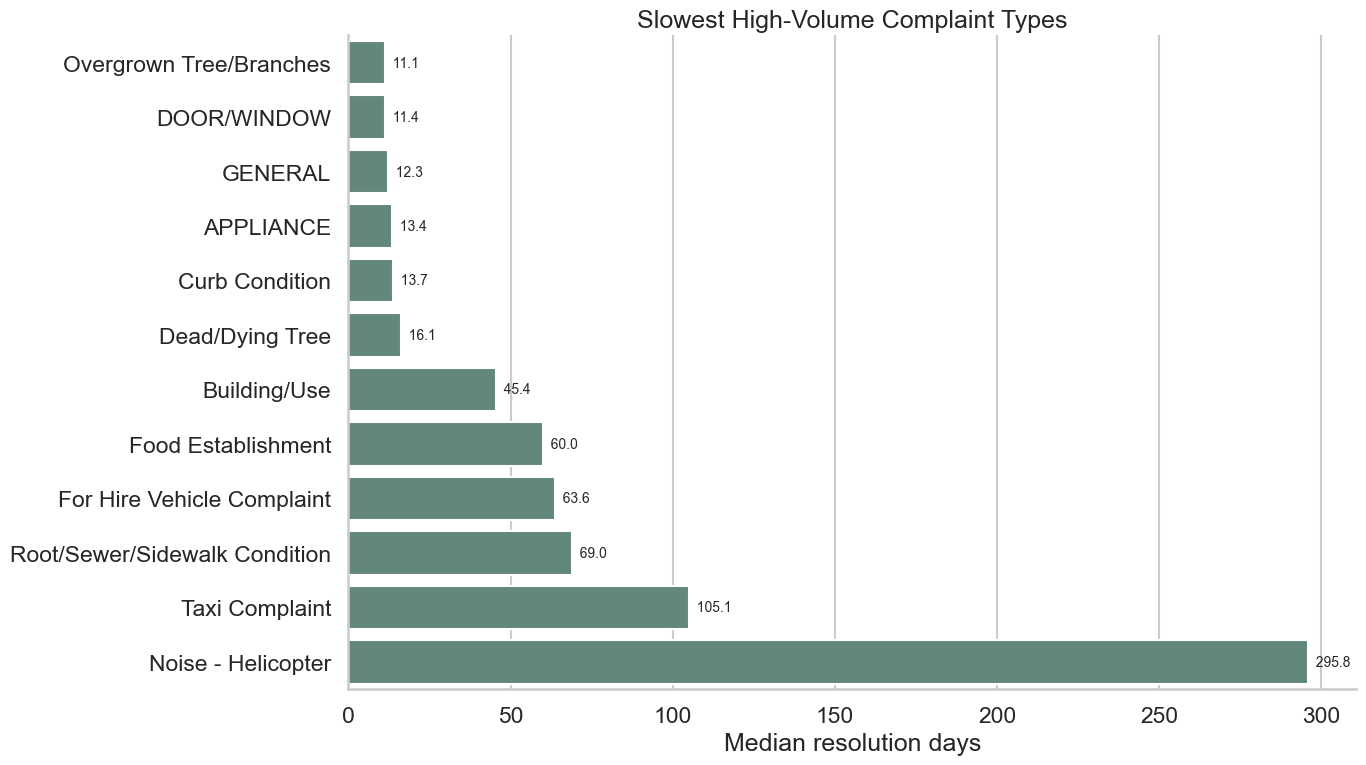

In [5]:
slow_complaints = (
    complaint_type_metrics.loc[complaint_type_metrics["complaints"] >= COMPLAINT_MIN]
    .sort_values(["median_resolution_days", "complaints"], ascending=[False, False])
    .head(12)
    .copy()
)

display(
    trim_table(
        slow_complaints[[
            "complaint_type",
            "complaints",
            "median_resolution_days",
            "p90_resolution_days",
            "unresolved_share",
            "top_agency",
        ]],
        percent_cols=["unresolved_share"],
        day_cols=["median_resolution_days", "p90_resolution_days"],
    )
)

plot_df = slow_complaints.sort_values("median_resolution_days", ascending=True)
fig, ax = plt.subplots(figsize=(14, 8))
sns.barplot(data=plot_df, x="median_resolution_days", y="complaint_type", color="#5B8E7D", ax=ax)
annotate_barh(ax)
ax.set_title("Slowest High-Volume Complaint Types")
ax.set_xlabel("Median resolution days")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## Agency Scorecards

Agency-wide rankings are descriptive. Workloads differ a lot, so the stronger comparison comes in the within-issue bottleneck view.

,agency,complaints,median_resolution_days,p90_resolution_days,unresolved_share,status_backlog_share,top_complaint_type
0,NYPD,2126094,0.1d,0.3d,0.0%,0.0%,Illegal Parking
1,HPD,1105804,3.1d,31.2d,6.0%,6.0%,HEAT/HOT WATER
2,DSNY,450912,1.4d,7.1d,1.9%,1.9%,Dirty Condition
3,DOT,308413,1.7d,14.1d,6.8%,8.1%,Street Condition
4,DEP,250406,0.9d,7.2d,2.9%,2.9%,Water System
5,DOB,133166,6.1d,119.5d,0.0%,12.5%,General Construction/Plumbing
6,DPR,130401,5.9d,95.0d,21.3%,21.3%,Damaged Tree
7,DOHMH,103295,1.0d,60.0d,8.9%,8.9%,Rodent
8,DHS,60691,0.3d,8.9d,10.6%,0.8%,Homeless Person Assistance
9,TLC,45994,41.0d,187.9d,36.3%,36.3%,For Hire Vehicle Complaint


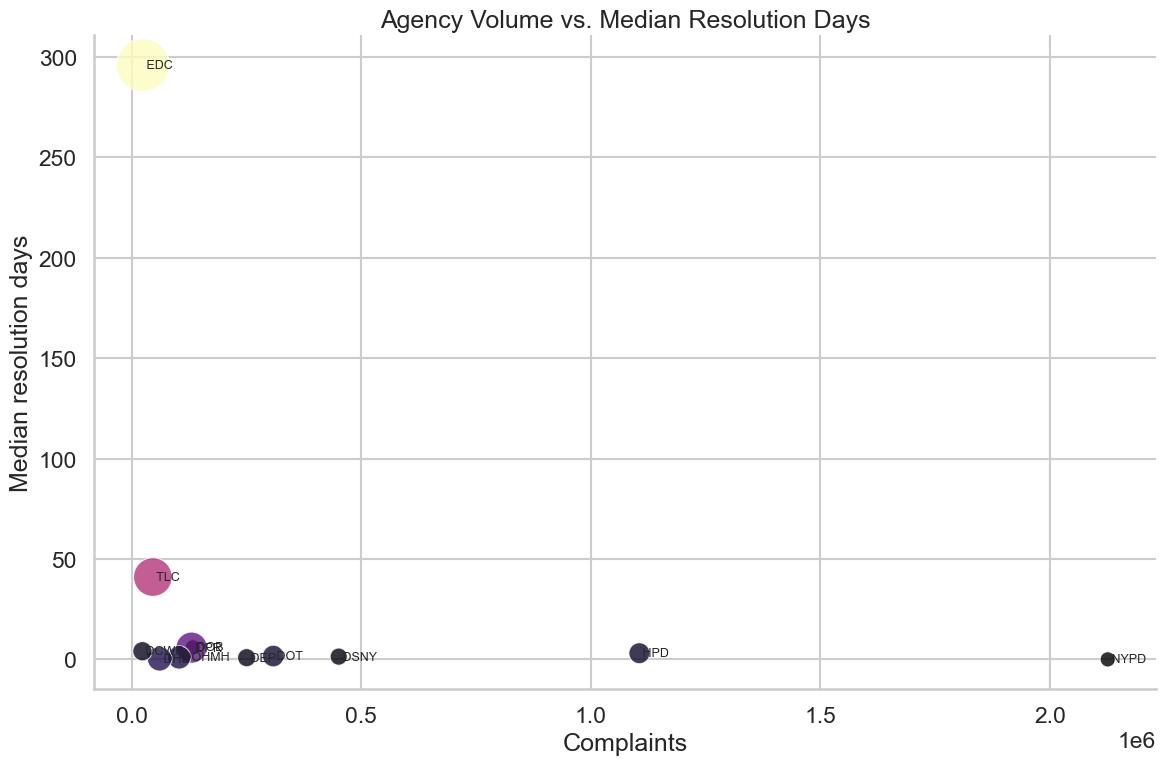

In [6]:
agency_scorecard = (
    agency_metrics.loc[agency_metrics["complaints"] >= AGENCY_MIN, [
        "agency",
        "complaints",
        "median_resolution_days",
        "p90_resolution_days",
        "unresolved_share",
        "status_backlog_share",
        "top_complaint_type",
    ]]
    .sort_values("complaints", ascending=False)
)

display(
    trim_table(
        agency_scorecard,
        percent_cols=["unresolved_share", "status_backlog_share"],
        day_cols=["median_resolution_days", "p90_resolution_days"],
    )
)

plot_df = agency_metrics.loc[agency_metrics["complaints"] >= AGENCY_MIN].copy()
plot_df["bubble_size"] = plot_df["unresolved_share"].mul(1800).add(120)
fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(
    plot_df["complaints"],
    plot_df["median_resolution_days"],
    s=plot_df["bubble_size"],
    c=plot_df["unresolved_share"],
    cmap="magma",
    alpha=0.8,
    edgecolor="white",
    linewidth=0.8,
)
for row in plot_df.itertuples(index=False):
    ax.text(row.complaints, row.median_resolution_days, f" {row.agency}", fontsize=9, va="center")
ax.set_title("Agency Volume vs. Median Resolution Days")
ax.set_xlabel("Complaints")
ax.set_ylabel("Median resolution days")
plt.tight_layout()
plt.show()

## Within-Issue Bottlenecks

This is the strongest Phase 6 view. It compares agencies inside the same complaint type, then measures how far each agency sits above that complaint type's overall median.

,issue_value,agency,complaints,median_resolution_days,issue_median_resolution_days,median_resolution_gap_days,unresolved_share
69,Highway Condition,DSNY,1108,14.0d,3.7d,10.2d,14.0%
18,Encampment,DHS,16989,1.8d,0.1d,1.8d,2.4%
44,Graffiti,DSNY,21921,9.2d,7.5d,1.7d,14.8%


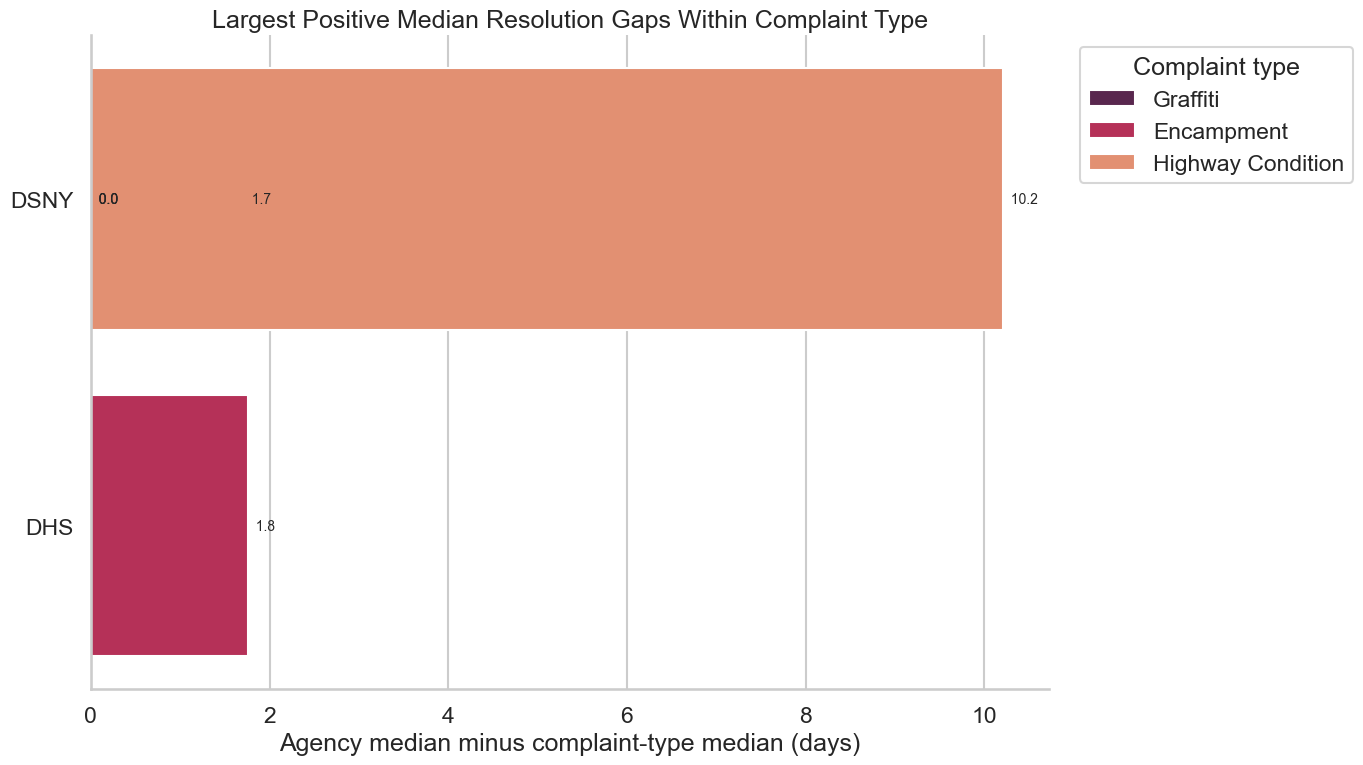

In [7]:
bottlenecks = (
    agency_issue_metrics.loc[
        (agency_issue_metrics["issue_level"] == "complaint_type")
        & (agency_issue_metrics["complaints"] >= ISSUE_CELL_MIN)
        & (agency_issue_metrics["median_resolution_gap_days"] > 0)
    ]
    .sort_values(["median_resolution_gap_days", "complaints"], ascending=[False, False])
    .head(12)
    .copy()
)

display(
    trim_table(
        bottlenecks[[
            "issue_value",
            "agency",
            "complaints",
            "median_resolution_days",
            "issue_median_resolution_days",
            "median_resolution_gap_days",
            "unresolved_share",
        ]],
        percent_cols=["unresolved_share"],
        day_cols=["median_resolution_days", "issue_median_resolution_days", "median_resolution_gap_days"],
    )
)

plot_df = bottlenecks.sort_values("median_resolution_gap_days", ascending=True)
fig, ax = plt.subplots(figsize=(14, 8))
sns.barplot(data=plot_df, x="median_resolution_gap_days", y="agency", hue="issue_value", dodge=False, palette="rocket", ax=ax)
annotate_barh(ax)
ax.set_title("Largest Positive Median Resolution Gaps Within Complaint Type")
ax.set_xlabel("Agency median minus complaint-type median (days)")
ax.set_ylabel("")
ax.legend(title="Complaint type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Monthly Operations Trends

Trend charts use only complete months. That keeps partial April 2026 volumes from inflating unresolved shares and making the YTD picture look worse than it is.

,created_month_start,created_year,complaints,median_resolution_days,p90_resolution_days,unresolved_share,status_backlog_share
0,2025-01-01,2025,348179,0.6d,16.1d,0.8%,0.6%
1,2025-02-01,2025,255364,0.6d,18.2d,1.5%,1.3%
2,2025-03-01,2025,281220,0.3d,19.2d,1.6%,1.1%
3,2025-04-01,2025,272550,0.3d,18.1d,2.1%,1.4%
4,2025-05-01,2025,295057,0.2d,15.3d,2.0%,2.0%
5,2025-06-01,2025,306435,0.1d,17.8d,2.0%,2.2%
6,2025-07-01,2025,315846,0.2d,19.4d,2.1%,2.4%
7,2025-08-01,2025,304009,0.2d,15.4d,2.4%,2.7%
8,2025-09-01,2025,302676,0.2d,12.7d,2.7%,3.0%
9,2025-10-01,2025,336611,0.2d,13.4d,2.8%,3.2%


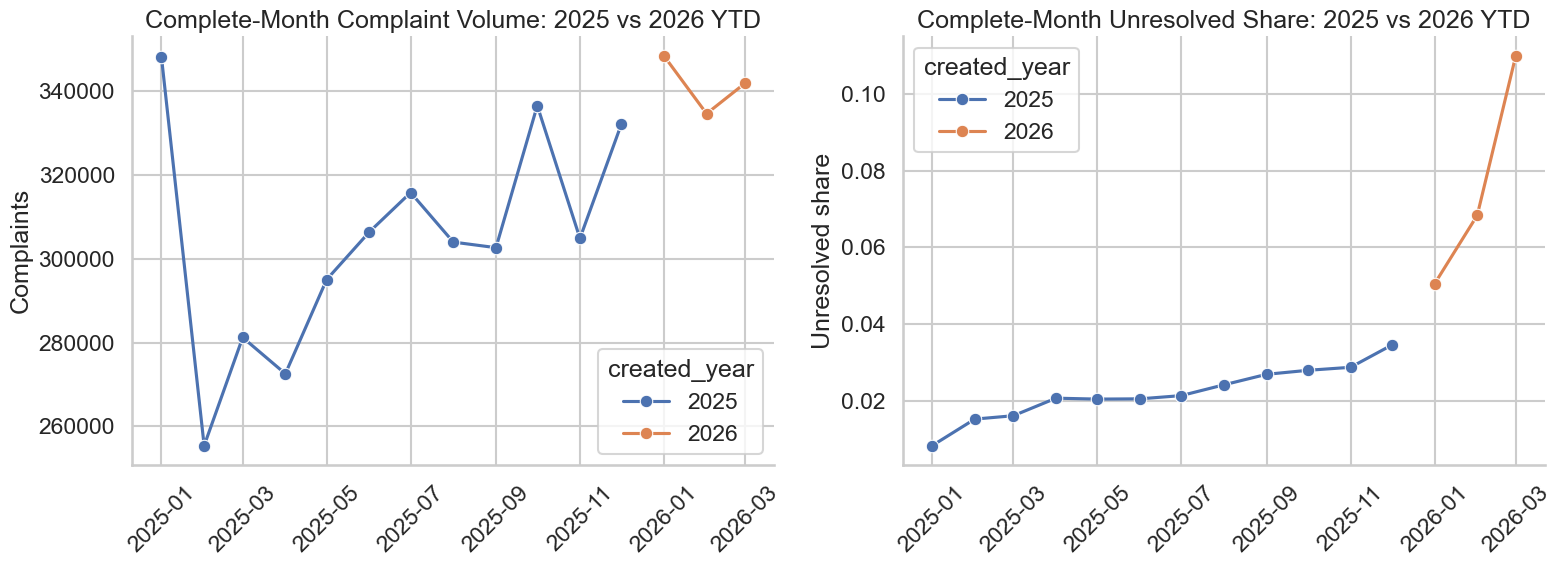

In [8]:
display(
    trim_table(
        aligned_citywide[[
            "created_month_start",
            "created_year",
            "complaints",
            "median_resolution_days",
            "p90_resolution_days",
            "unresolved_share",
            "status_backlog_share",
        ]],
        percent_cols=["unresolved_share", "status_backlog_share"],
        day_cols=["median_resolution_days", "p90_resolution_days"],
    )
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
sns.lineplot(data=aligned_citywide, x="created_month_start", y="complaints", hue="created_year", marker="o", palette="deep", ax=axes[0])
sns.lineplot(data=aligned_citywide, x="created_month_start", y="unresolved_share", hue="created_year", marker="o", palette="deep", ax=axes[1])
axes[0].set_title("Complete-Month Complaint Volume: 2025 vs 2026 YTD")
axes[0].set_xlabel("")
axes[0].set_ylabel("Complaints")
axes[1].set_title("Complete-Month Unresolved Share: 2025 vs 2026 YTD")
axes[1].set_xlabel("")
axes[1].set_ylabel("Unresolved share")
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

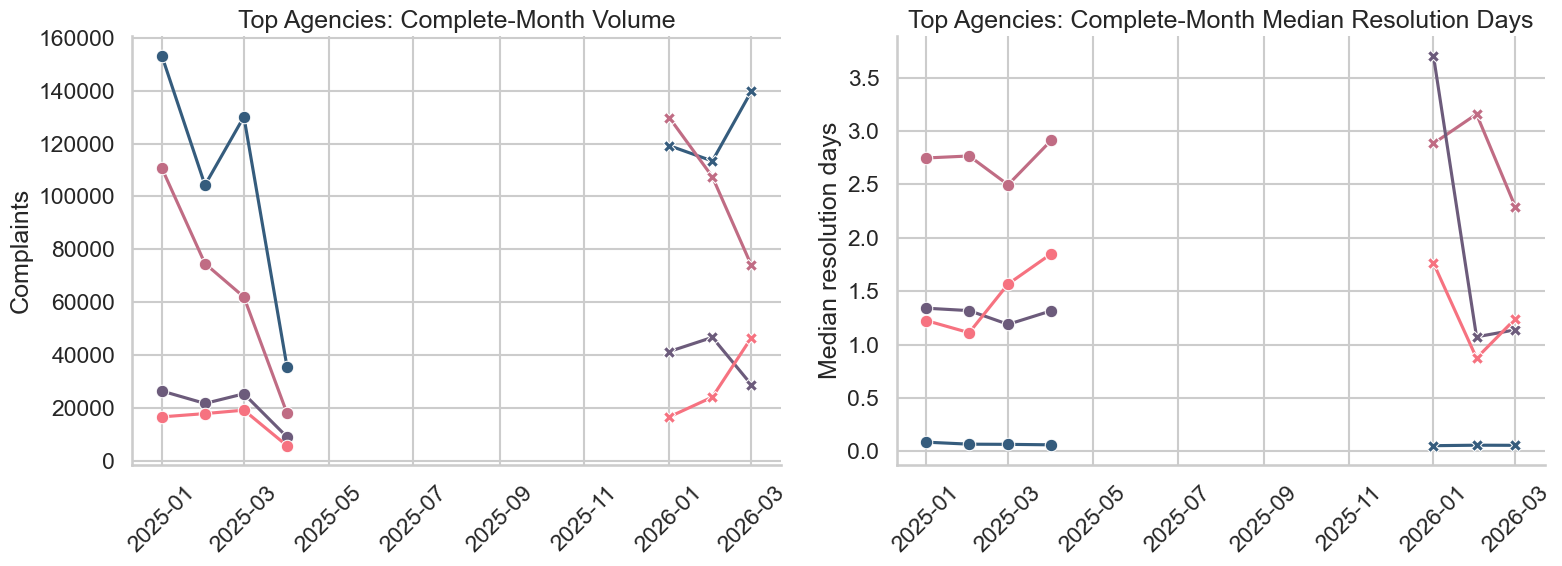

In [9]:
top_agencies = agency_metrics.head(TOP_AGENCY_COUNT)["agency"].tolist()
agency_monthly = build_segment_monthly_metrics(
    complete_months.loc[complete_months["agency"].isin(top_agencies)],
    "agency",
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
for agency in top_agencies:
    agency_slice = agency_monthly.loc[agency_monthly["agency"].eq(agency)]
    color = AGENCY_COLORS.get(agency)
    sns.lineplot(
        data=agency_slice,
        x="created_month_start",
        y="complaints",
        hue="created_year",
        style="created_year",
        markers=True,
        dashes=False,
        palette=[color, color] if color else "deep",
        legend=False,
        ax=axes[0],
    )
    sns.lineplot(
        data=agency_slice,
        x="created_month_start",
        y="median_resolution_days",
        hue="created_year",
        style="created_year",
        markers=True,
        dashes=False,
        palette=[color, color] if color else "deep",
        legend=False,
        ax=axes[1],
    )
axes[0].set_title("Top Agencies: Complete-Month Volume")
axes[0].set_xlabel("")
axes[0].set_ylabel("Complaints")
axes[1].set_title("Top Agencies: Complete-Month Median Resolution Days")
axes[1].set_xlabel("")
axes[1].set_ylabel("Median resolution days")
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## Neighborhood Operations View

Community boards remain the strongest neighborhood comparison unit for operations because the analytic dataset has near-complete coverage there.

,community_board,complaints,median_resolution_days,p90_resolution_days,unresolved_share,top_agency,top_complaint_type
8,06 BRONX,64916,1.2d,19.9d,3.3%,HPD,HEAT/HOT WATER
11,02 BRONX,36526,1.1d,23.2d,4.6%,HPD,HEAT/HOT WATER
22,17 BROOKLYN,84468,1.1d,18.0d,3.4%,HPD,HEAT/HOT WATER
1,04 BRONX,119846,1.0d,18.3d,3.7%,HPD,HEAT/HOT WATER
38,10 MANHATTAN,108461,1.0d,20.5d,3.7%,HPD,HEAT/HOT WATER
3,05 BRONX,101399,1.0d,18.9d,3.7%,HPD,HEAT/HOT WATER
30,09 BROOKLYN,66351,0.9d,17.1d,3.3%,HPD,HEAT/HOT WATER
20,03 BROOKLYN,90608,0.9d,17.3d,4.5%,NYPD,Noise - Residential
2,07 BRONX,106795,0.9d,16.7d,3.6%,HPD,HEAT/HOT WATER
24,08 BROOKLYN,75614,0.9d,18.9d,7.1%,NYPD,Illegal Parking


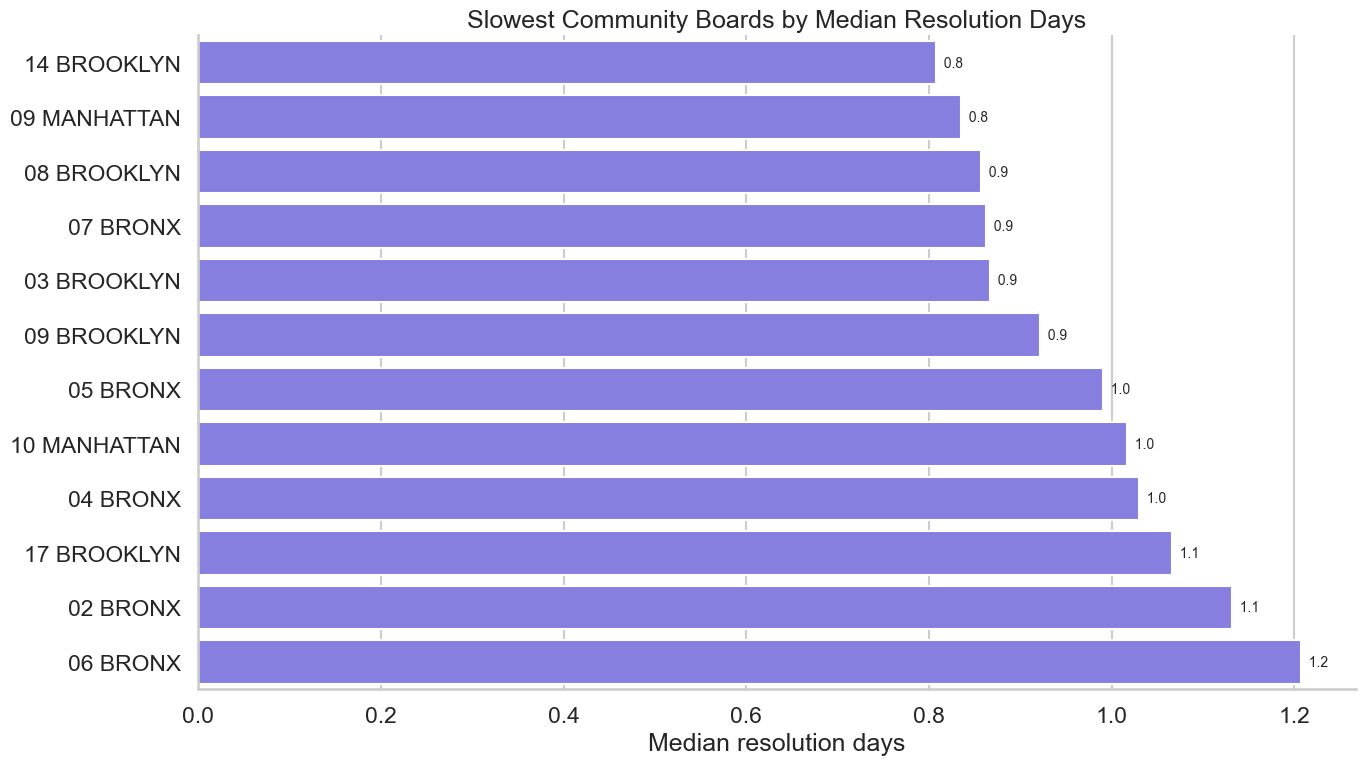

In [10]:
slow_boards = (
    community_board_operations.loc[community_board_operations["complaints"] >= BOARD_MIN]
    .sort_values(["median_resolution_days", "complaints"], ascending=[False, False])
    .head(12)
    .copy()
)

display(
    trim_table(
        slow_boards[[
            "community_board",
            "complaints",
            "median_resolution_days",
            "p90_resolution_days",
            "unresolved_share",
            "top_agency",
            "top_complaint_type",
        ]],
        percent_cols=["unresolved_share"],
        day_cols=["median_resolution_days", "p90_resolution_days"],
    )
)

plot_df = slow_boards.sort_values("median_resolution_days", ascending=True)
fig, ax = plt.subplots(figsize=(14, 8))
sns.barplot(data=plot_df, x="median_resolution_days", y="community_board", color="#7A6FF0", ax=ax)
annotate_barh(ax)
ax.set_title("Slowest Community Boards by Median Resolution Days")
ax.set_xlabel("Median resolution days")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## Findings

The goal is a short operations readout, not a wall of rankings.

In [11]:
top_slowest_complaint = slow_complaints.iloc[0]
top_agency = agency_metrics.iloc[0]
top_bottleneck = bottlenecks.iloc[0]
top_slowest_board = slow_boards.iloc[0]

so_what = pd.DataFrame(
    [
        {
            "question": "Where is the slowest high-volume complaint work?",
            "answer": f"{top_slowest_complaint['complaint_type']} is the slowest complaint type among categories with at least {COMPLAINT_MIN:,} complaints.",
            "evidence": f"Median {top_slowest_complaint['median_resolution_days']:.1f} days, p90 {top_slowest_complaint['p90_resolution_days']:.1f}, unresolved share {top_slowest_complaint['unresolved_share']:.1%}.",
        },
        {
            "question": "Who carries the most system volume?",
            "answer": f"{top_agency['agency']} handles the most complaints in the scoped window.",
            "evidence": f"{int(top_agency['complaints']):,} complaints with median resolution {top_agency['median_resolution_days']:.2f} days.",
        },
        {
            "question": "What is the clearest within-issue bottleneck?",
            "answer": f"{top_bottleneck['agency']} on {top_bottleneck['issue_value']} sits furthest above its complaint-type benchmark in the high-volume cells.",
            "evidence": f"Median gap {top_bottleneck['median_resolution_gap_days']:.1f} days across {int(top_bottleneck['complaints']):,} complaints.",
        },
        {
            "question": "Which neighborhood operations area looks slowest?",
            "answer": f"{top_slowest_board['community_board']} is the slowest high-volume community board in this Phase 6 cut.",
            "evidence": f"Median {top_slowest_board['median_resolution_days']:.2f} days, p90 {top_slowest_board['p90_resolution_days']:.1f}, unresolved share {top_slowest_board['unresolved_share']:.1%}.",
        },
        {
            "question": "Why exclude April 2026 from the trend charts?",
            "answer": "Because it is a partial month and would mechanically overstate backlog and unresolved shares.",
            "evidence": "The complete-month view keeps the 2025 vs 2026 YTD comparison operationally fair.",
        },
    ]
)
display(so_what)

,question,answer,evidence
0,Where is the slowest high-volume complaint work?,Noise - Helicopter is the slowest complaint ty...,"Median 295.8 days, p90 341.0, unresolved share..."
1,Who carries the most system volume?,NYPD handles the most complaints in the scoped...,"2,126,094 complaints with median resolution 0...."
2,What is the clearest within-issue bottleneck?,DSNY on Highway Condition sits furthest above ...,"Median gap 10.2 days across 1,108 complaints."
3,Which neighborhood operations area looks slowest?,06 BRONX is the slowest high-volume community ...,"Median 1.21 days, p90 19.9, unresolved share 3..."
4,Why exclude April 2026 from the trend charts?,Because it is a partial month and would mechan...,The complete-month view keeps the 2025 vs 2026...
